# Enhancer hijacking — RNA-seq (junction / event-centred frame)

Same RNA-seq readout as `tss_centered/rna_seq_analysis.ipynb`, but on  the window is centred on the *junction*

In [1]:
import os, sys
for p in ['.', '..', '../..', '../../..']:
    if os.path.isdir(os.path.join(p, 'fusionseq')): sys.path.insert(0, os.path.abspath(p)); break
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from alphagenome.models import dna_client

pd.set_option('display.max_columns', None)
DATA = next(d for d in ('data', '../data', 'v2/data', '../v2/data', '../../data') if os.path.isdir(d))
frame = pd.read_csv(f'{DATA}/event_site_centered_data.csv')

def _api_key():
    k = os.environ.get('ALPHA_GENOME_API_KEY')
    if k:
        return k
    for p in ('.env', '../.env', '../../.env', '../../../.env'):
        if os.path.exists(p):
            for line in open(p):
                if line.startswith('ALPHA_GENOME_API_KEY='):
                    return line.split('=', 1)[1].strip().strip('"\'')
    raise RuntimeError('ALPHA_GENOME_API_KEY not found')

model = dna_client.create(_api_key())
RNA = dna_client.OutputType.RNA_SEQ
W = 1_048_576

def predict_rna(seq, ontology, strand):
    td = model.predict_sequence(seq, requested_outputs=[RNA], ontology_terms=[ontology]).rna_seq
    vals, meta = np.asarray(td.values), td.metadata
    cols = np.where(meta['strand'].values == strand)[0]
    if len(cols) == 0:
        cols = np.where(meta['strand'].values == '.')[0]
    assert len(cols), f'no RNA-seq track for {ontology}'
    return vals[:, cols].mean(axis=1)

/home/codingnewt/MLCB/Borzoi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import json, urllib.request

TRANSCRIPTS = {'EVI1 (MECOM)': 'ENST00000264674', 'TAL1': 'ENST00000691006',
               'ETV1': 'ENST00000430479', 'MNX1': 'ENST00000252971'}

def fetch_exons(tx):
    url = f'https://rest.ensembl.org/lookup/id/{tx}?expand=1;content-type=application/json'
    return [(e['start'], e['end']) for e in json.load(urllib.request.urlopen(url, timeout=60))['Exon']]

exons = {g: fetch_exons(tx) for g, tx in TRANSCRIPTS.items()}

In [3]:
# TSS sits at window index `center` (= readout_bp); the enhancer (`enh`, genomic-equivalent span on
# the onco-arm scale) is marked as the orange box, same as the TSS-centred notebooks.
def _annot(ax, span, exon_list, ga, gb, gene, half, eh, enh=None):
    for s, e in exon_list:
        a, b = span(s, e)
        ax.add_patch(plt.Rectangle((min(a, b), -1.5 * eh), max(abs(b - a), 0.05), eh,
                                   color='firebrick', lw=0, zorder=5, clip_on=True))
    if enh is not None:
        ex0, ex1 = span(*enh)
        if ex1 >= -half and ex0 <= half:
            ax.add_patch(plt.Rectangle((max(ex0, -half), -1.5 * eh), min(ex1, half) - max(ex0, -half), eh,
                                       color='darkorange', lw=0, zorder=6, clip_on=True))
    ax.plot([max(ga, -half), min(gb, half)], [-2.7 * eh, -2.7 * eh],
            lw=4, color='seagreen', solid_capstyle='butt', zorder=5, clip_on=True)
    if half <= 75:
        ax.text(np.clip((ga + gb) / 2, -half, half), -2.7 * eh, gene.split()[0],
                ha='center', va='center', fontsize=8, fontweight='bold', color='white', zorder=7,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='seagreen', edgecolor='none'))

def _legend(ax, with_wt=True, enh=None):
    h = []
    if with_wt:
        h += [Line2D([0], [0], color='steelblue', lw=1.5, label='der'),
              Line2D([0], [0], color='0.55', lw=1.5, ls='--', label='WT')]
    h += [Patch(facecolor='seagreen', label='gene'), Patch(facecolor='firebrick', label='exon')]
    if enh is not None:
        h.append(Patch(facecolor='darkorange', label='enhancer'))
    ax.legend(handles=h, loc='upper right', fontsize=7, frameon=True, framealpha=0.9)

def plot_locus(gene, track, center, tss, strand, exon_list, title, desc):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - center) / 1000              # kb from TSS (TSS at window index `center`)
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    fig, (over, detail) = plt.subplots(2, 1, figsize=(10, 5.4))
    for ax, half in [(over, W // 2 / 1000), (detail, 75)]:
        vis = np.abs(x) <= half
        ymax = max(float(track[vis].max()) * 1.15, 1e-4); eh = ymax * 0.05
        ax.plot(x, track, lw=0.5, color='steelblue', zorder=3)
        ax.axhline(0, color='0.7', lw=0.5, zorder=2); ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
        _annot(ax, span, exon_list, ga, gb, gene, half, eh)
        ax.set_xlim(-half, half); ax.set_ylim(-3.7 * eh, ymax); ax.set_ylabel('pred RNA-seq')
    _legend(over, with_wt=False)
    over.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    detail.set_xlabel('kb from TSS (junction frame; gene body = positive)')
    fig.tight_layout()

def plot_overlay(gene, wt, der, center, tss, strand, exon_list, title, desc, enh=None):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - center) / 1000
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    fig, (over, detail) = plt.subplots(2, 1, figsize=(10, 5.4))
    for ax, half in [(over, W // 2 / 1000), (detail, 75)]:
        vis = np.abs(x) <= half
        ymax = max(float(max(wt[vis].max(), der[vis].max())) * 1.15, 1e-4); eh = ymax * 0.05
        ax.plot(x, wt,  lw=0.8, color='0.55', ls='--', zorder=3)
        ax.plot(x, der, lw=0.9, color='steelblue', zorder=4)
        ax.axhline(0, color='0.7', lw=0.5, zorder=2); ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
        _annot(ax, span, exon_list, ga, gb, gene, half, eh, enh=enh)
        ax.set_xlim(-half, half); ax.set_ylim(-3.7 * eh, ymax); ax.set_ylabel('pred RNA-seq')
    _legend(over, enh=enh)
    over.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    detail.set_xlabel('kb from TSS (junction frame; gene body = positive)')
    fig.tight_layout()

def plot_genezoom(gene, wt, der, center, tss, strand, exon_list, title, desc, enh=None, pad_kb=10):
    flip = -1 if strand == '-' else 1
    x = flip * (np.arange(W) - center) / 1000
    span = lambda s, e: sorted((flip * (s - tss) / 1000, flip * (e - tss) / 1000))
    ga, gb = span(min(s for s, e in exon_list), max(e for s, e in exon_list))
    lo, hi = ga - pad_kb, gb + pad_kb
    vis = (x >= lo) & (x <= hi)
    ymax = max(float(max(wt[vis].max(), der[vis].max())) * 1.15, 1e-4); eh = ymax * 0.05
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.plot(x, wt,  lw=0.9, color='0.55', ls='--', zorder=3)
    ax.plot(x, der, lw=1.0, color='steelblue', zorder=4)
    ax.axhline(0, color='0.7', lw=0.5, zorder=2); ax.axvline(0, color='0.7', ls=':', lw=0.7, zorder=2)
    _annot(ax, span, exon_list, ga, gb, gene, max(hi, -lo), eh, enh=enh)
    ax.set_xlim(lo, hi); ax.set_ylim(-3.7 * eh, ymax); ax.set_ylabel('pred RNA-seq')
    ax.set_xlabel('kb from TSS (junction frame; gene body = positive)')
    _legend(ax, enh=enh)
    ax.set_title(f"{title}\n{desc}", fontsize=10, loc='left')
    fig.tight_layout()

## WT baselines

The oncogene locus alone (no rearrangement), read at its TSS.

In [4]:
# one row per oncogene; the enhancer sits at the junction end of the partner arm
work = frame.dropna(subset=['onco_tss']).drop_duplicates('driven_gene').reset_index(drop=True).copy()
work['onco_tss']   = work['onco_tss'].astype(int)
work['readout_bp'] = work['readout_bp'].astype(int)
L = W // 2
work['enh'] = [(int(r.onco_tss) + L - int(r.readout_bp) - (int(r.enh_end) - int(r.enh_start)),
                int(r.onco_tss) + L - int(r.readout_bp)) for r in work.itertuples()]
work['wt_track']  = [predict_rna(r.wt_seq,  r.ontology, r.strand) for r in work.itertuples()]
work['der_track'] = [predict_rna(r.der_seq, r.ontology, r.strand) for r in work.itertuples()]
work[['name', 'driven_gene', 'tss_to_junction_kb', 'readout_bp', 'cell_context']]

,name,driven_gene,tss_to_junction_kb,readout_bp,cell_context
0,GATA2-MECOM,EVI1 (MECOM),40,564288,"K562 (GATA2+, EVI1-silent)"
1,TCR-TAL1,TAL1,20,544288,CD4 T-cell (TAL1-silent)
2,ETV6-MNX1,MNX1,20,544288,CD34+ CMP (MNX1-silent)
3,MIPOL1-ETV1,ETV1,400,924288,LNCaP prostate adenoca (ETV1-low in normal pro...


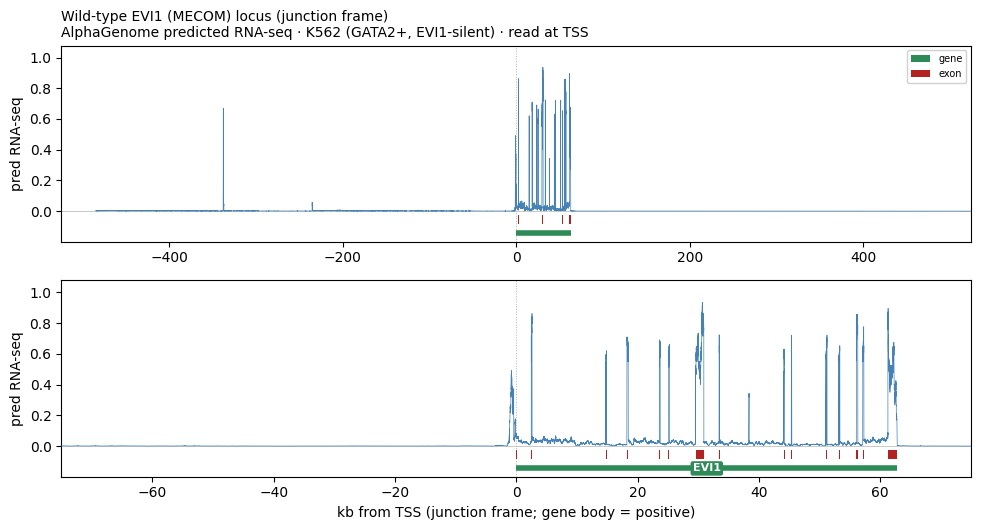

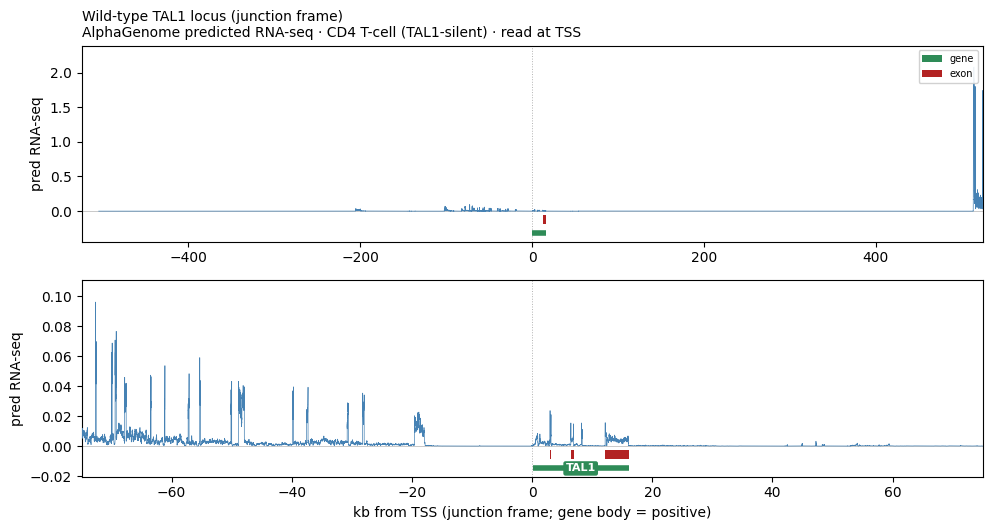

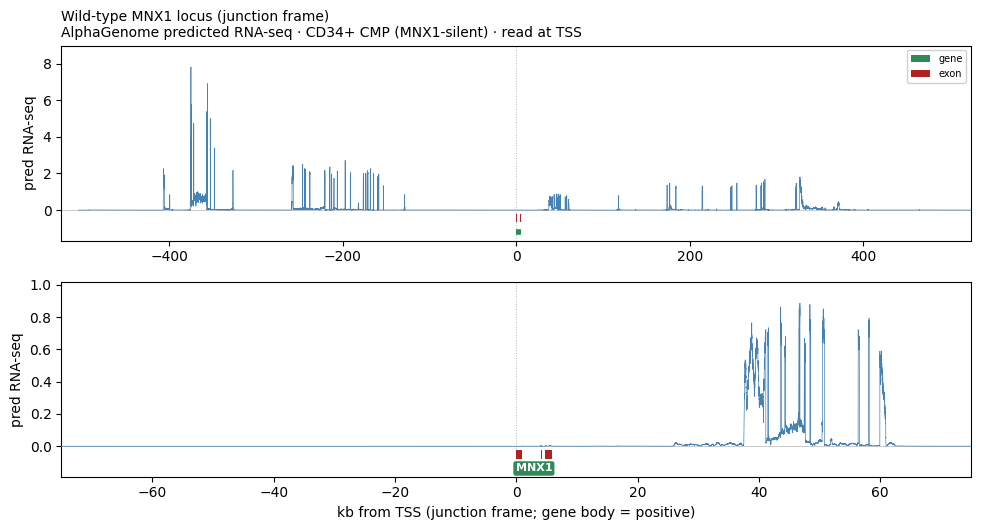

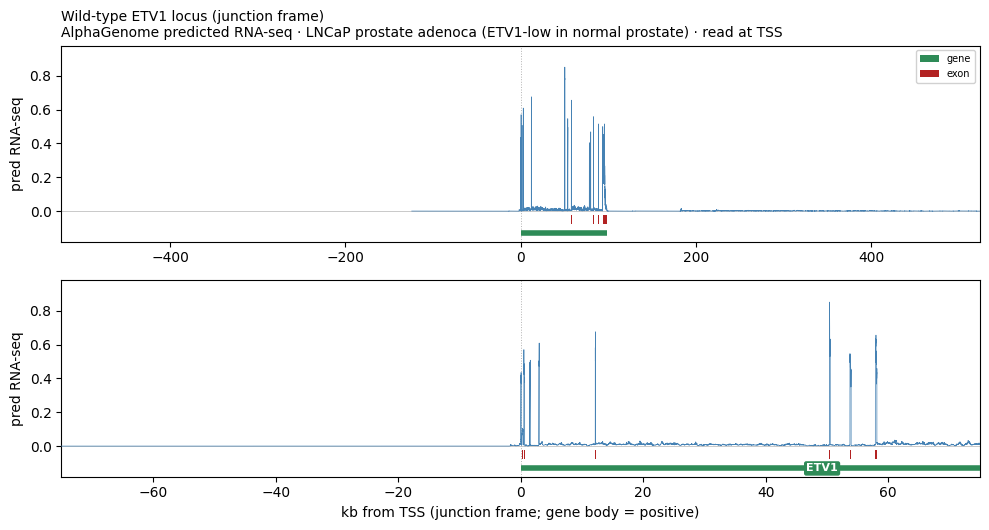

In [5]:
for r in work.itertuples():
    plot_locus(r.driven_gene, r.wt_track, r.readout_bp, r.onco_tss, r.strand, exons[r.driven_gene],
               f"Wild-type {r.driven_gene} locus (junction frame)",
               f"AlphaGenome predicted RNA-seq \u00b7 {r.cell_context} \u00b7 read at TSS")

## WT vs der overlay

WT (gray dashed) vs the faithful junction derivative (blue). der gaining signal on the gene's own exons = capture; orange = the hijacked enhancer (junction end of the partner arm).

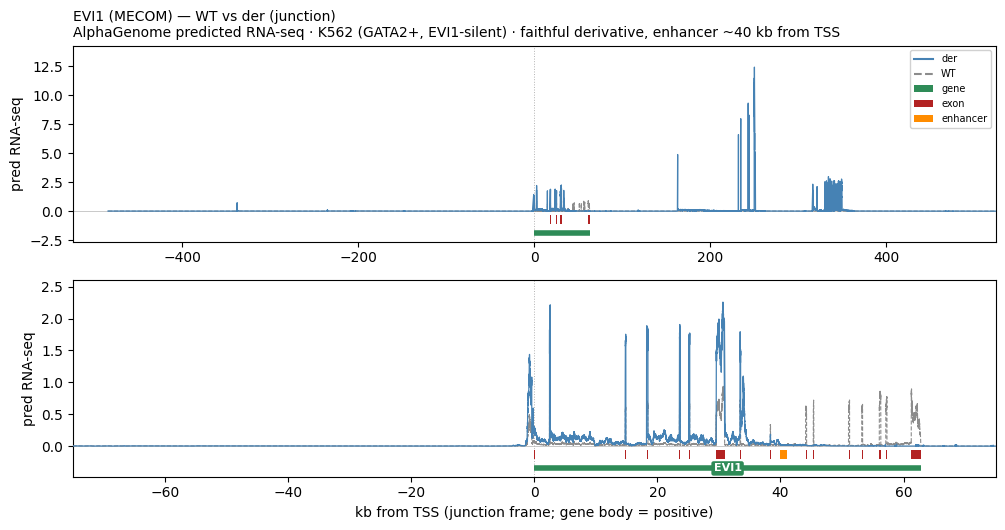

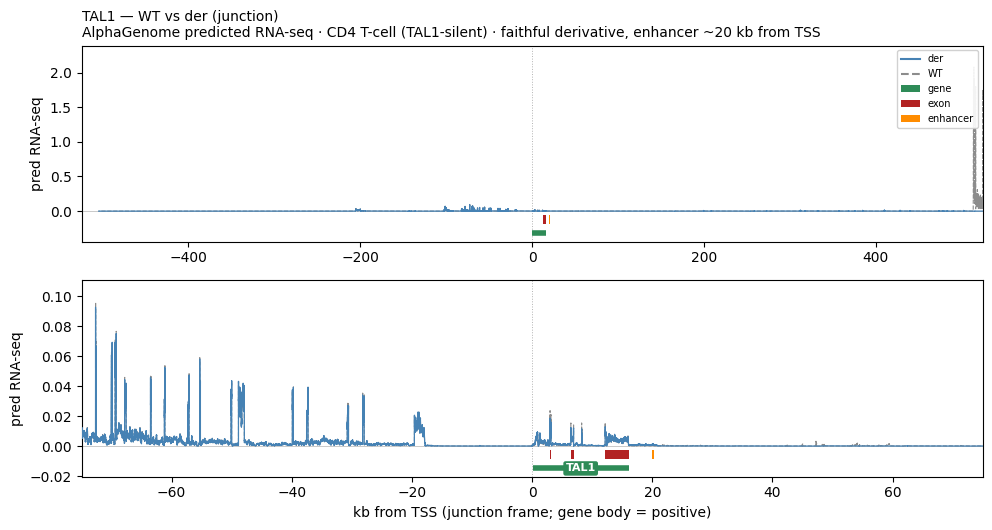

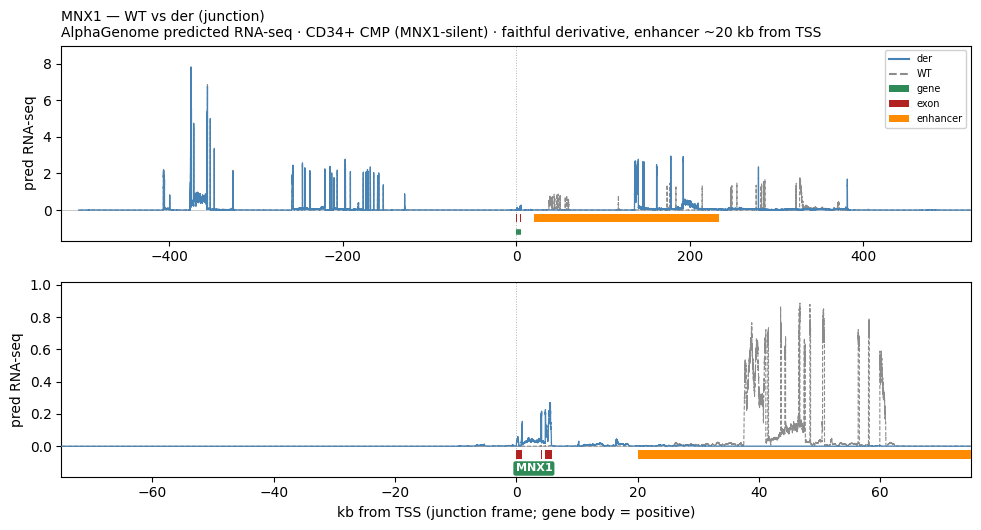

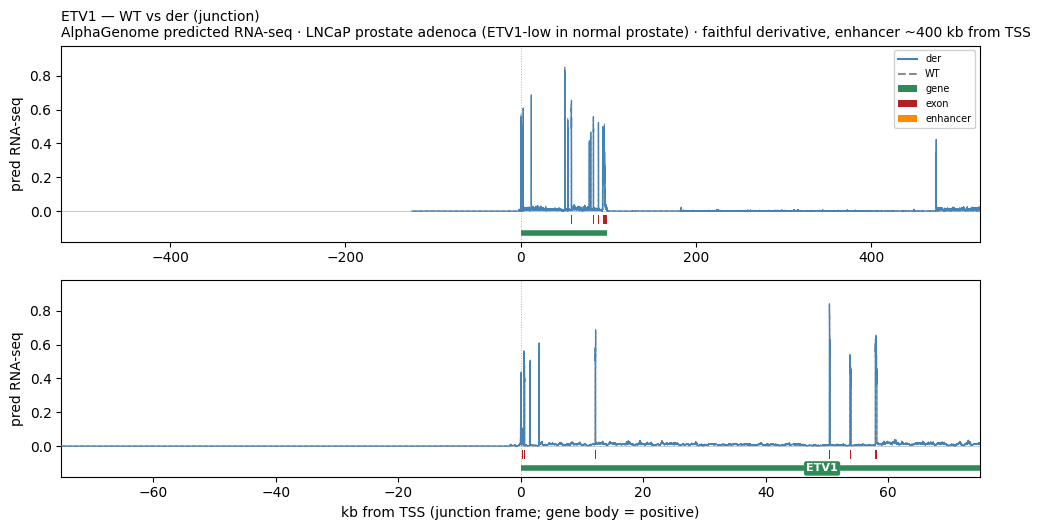

In [6]:
for r in work.itertuples():
    plot_overlay(r.driven_gene, r.wt_track, r.der_track, r.readout_bp, r.onco_tss, r.strand, exons[r.driven_gene],
                 f"{r.driven_gene} \u2014 WT vs der (junction)",
                 f"AlphaGenome predicted RNA-seq \u00b7 {r.cell_context} \u00b7 faithful derivative, enhancer ~{r.tss_to_junction_kb} kb from TSS",
                 enh=r.enh)

## Gene close-up (WT vs der)

Zoomed to the gene body +/-10 kb.

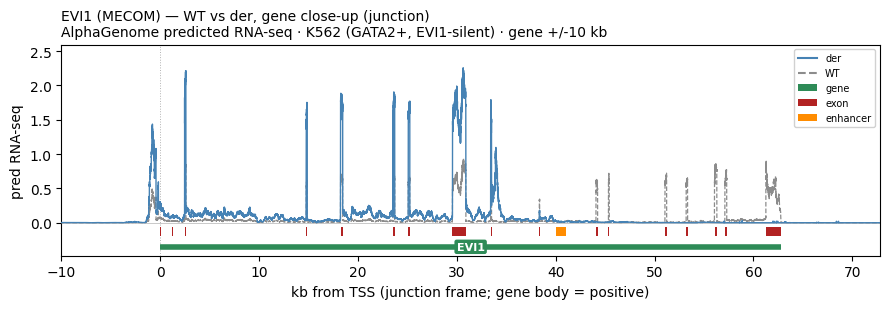

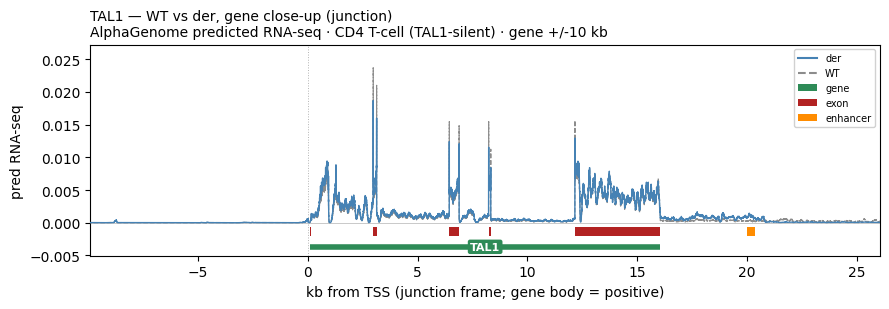

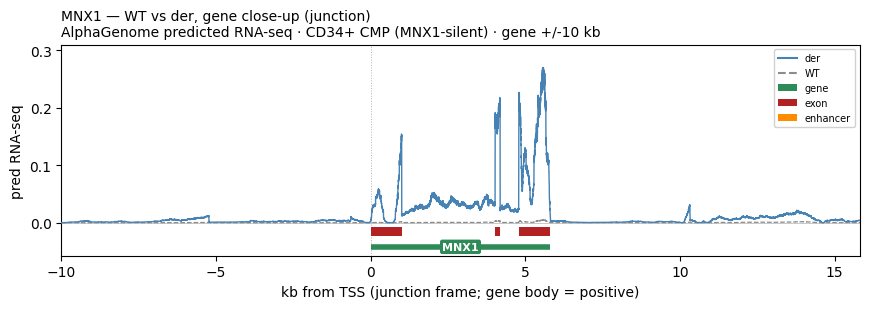

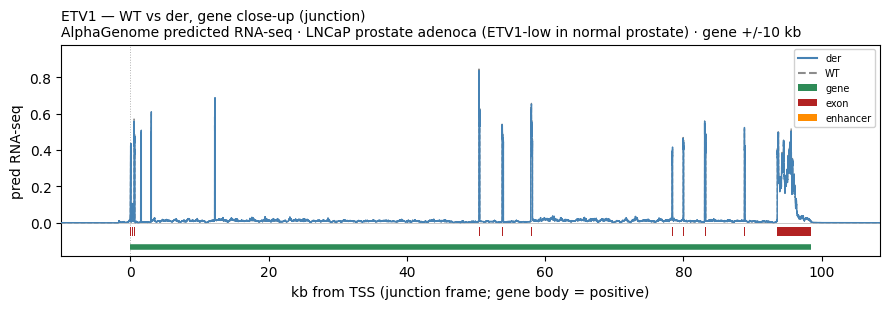

In [7]:
for r in work.itertuples():
    plot_genezoom(r.driven_gene, r.wt_track, r.der_track, r.readout_bp, r.onco_tss, r.strand, exons[r.driven_gene],
                  f"{r.driven_gene} \u2014 WT vs der, gene close-up (junction)",
                  f"AlphaGenome predicted RNA-seq \u00b7 {r.cell_context} \u00b7 gene +/-10 kb",
                  enh=r.enh)